In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/vsnsrohitponnuru007/house-prices/Housing.csv


# AI & ML Internship - Task 3
## Linear Regression

### Objective

The objective of this task is to implement and understand simple and multiple linear regression.

### Dataset

House Prices Dataset

### Tools Used

- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib

### Tasks Performed

1. Import and preprocess the dataset
2. Split the data into training and testing sets
3. Implement Simple Linear Regression
4. Implement Multiple Linear Regression
5. Evaluate models using MAE, MSE and R²
6. Plot regression results
7. Interpret regression coefficients

In [2]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/vsnsrohitponnuru007/house-prices/Housing.csv


In [4]:
# Load the training dataset

df = pd.read_csv(
    "/kaggle/input/datasets/vsnsrohitponnuru007/house-prices/Housing.csv"
)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
# Check columns, data types and missing values

print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Columns:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Missing values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Data types:
price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object


In [6]:
# Basic dataset information

print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

Dataset Shape: (545, 13)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [7]:
# Check for missing values

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [8]:
# Encode categorical variables

yes_no_columns = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

# Convert yes/no to 1/0
for column in yes_no_columns:
    df[column] = df[column].replace({'yes': 1, 'no': 0})

# One-hot encode furnishing status
df = pd.get_dummies(
    df,
    columns=['furnishingstatus'],
    drop_first=True,
    dtype=int
)

print("Encoding completed successfully!")
print("\nColumns after encoding:")
print(df.columns.tolist())

display(df.head())

Encoding completed successfully!

Columns after encoding:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


/tmp/ipykernel_16/1189379532.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[column] = df[column].replace({'yes': 1, 'no': 0})


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


In [9]:
# Check for missing values after encoding

print("Total NaN values:", df.isnull().sum().sum())

print("\nMissing values by column:")
print(df.isnull().sum())

Total NaN values: 0

Missing values by column:
price                              0
area                               0
bedrooms                           0
bathrooms                          0
stories                            0
mainroad                           0
guestroom                          0
basement                           0
hotwaterheating                    0
airconditioning                    0
parking                            0
prefarea                           0
furnishingstatus_semi-furnished    0
furnishingstatus_unfurnished       0
dtype: int64


In [10]:
# Separate features and target

X = df.drop('price', axis=1)
y = df['price']

print("X shape:", X.shape)
print("y shape:", y.shape)

print("NaN values in X:", X.isnull().sum().sum())
print("NaN values in y:", y.isnull().sum())

X shape: (545, 13)
y shape: (545,)
NaN values in X: 0
NaN values in y: 0


In [11]:
print(df.dtypes)

price                              int64
area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
mainroad                           int64
guestroom                          int64
basement                           int64
hotwaterheating                    int64
airconditioning                    int64
parking                            int64
prefarea                           int64
furnishingstatus_semi-furnished    int64
furnishingstatus_unfurnished       int64
dtype: object


In [12]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (436, 13)
Testing data: (109, 13)


In [13]:
# Simple Linear Regression

X_simple = df[['area']]
y_simple = df['price']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple,
    y_simple,
    test_size=0.2,
    random_state=42
)

simple_model = LinearRegression()

simple_model.fit(X_train_s, y_train_s)

y_pred_simple = simple_model.predict(X_test_s)

print("Simple Linear Regression completed!")

Simple Linear Regression completed!


In [14]:
# Regression equation

print("Intercept:", simple_model.intercept_)
print("Coefficient for Area:", simple_model.coef_[0])

Intercept: 2512254.2639593435
Coefficient for Area: 425.72984193878284


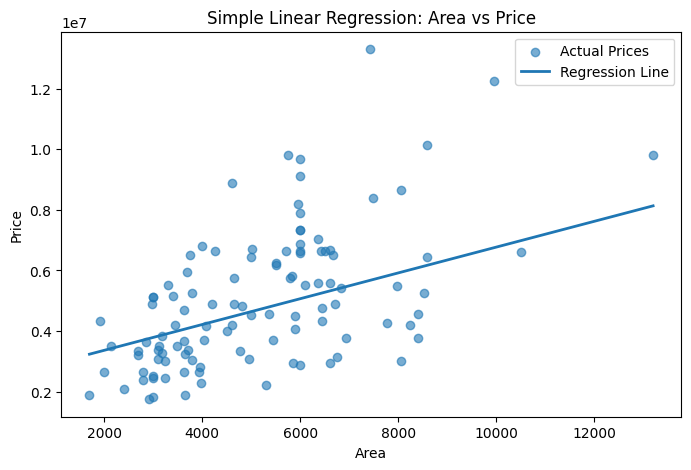

In [15]:
# Plot Simple Linear Regression

plt.figure(figsize=(8, 5))

plt.scatter(
    X_test_s['area'],
    y_test_s,
    alpha=0.6,
    label='Actual Prices'
)

sort_index = X_test_s['area'].argsort()

plt.plot(
    X_test_s['area'].iloc[sort_index],
    y_pred_simple[sort_index],
    linewidth=2,
    label='Regression Line'
)

plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Simple Linear Regression: Area vs Price')
plt.legend()
plt.show()

In [16]:
# Evaluate Simple Linear Regression

mae_simple = mean_absolute_error(y_test_s, y_pred_simple)
mse_simple = mean_squared_error(y_test_s, y_pred_simple)
r2_simple = r2_score(y_test_s, y_pred_simple)

print("Simple Linear Regression Results")
print("--------------------------------")
print("MAE:", mae_simple)
print("MSE:", mse_simple)
print("R² Score:", r2_simple)

Simple Linear Regression Results
--------------------------------
MAE: 1474748.1337969352
MSE: 3675286604768.185
R² Score: 0.27287851871974644


## Multiple Linear Regression

Multiple Linear Regression uses multiple independent variables to predict house price.

The model uses all available features after categorical variables have been encoded.

In [17]:
# Multiple Linear Regression

multiple_model = LinearRegression()

multiple_model.fit(X_train, y_train)

y_pred_multiple = multiple_model.predict(X_test)

print("Multiple Linear Regression completed successfully!")

Multiple Linear Regression completed successfully!


In [18]:
# Evaluate Multiple Linear Regression

mae_multiple = mean_absolute_error(y_test, y_pred_multiple)
mse_multiple = mean_squared_error(y_test, y_pred_multiple)
r2_multiple = r2_score(y_test, y_pred_multiple)

print("Multiple Linear Regression Results")
print("----------------------------------")
print("MAE:", mae_multiple)
print("MSE:", mse_multiple)
print("R² Score:", r2_multiple)

Multiple Linear Regression Results
----------------------------------
MAE: 970043.4039201637
MSE: 1754318687330.6633
R² Score: 0.6529242642153185


In [19]:
# Compare Simple and Multiple Linear Regression

comparison = pd.DataFrame({
    'Model': [
        'Simple Linear Regression',
        'Multiple Linear Regression'
    ],
    'MAE': [
        mae_simple,
        mae_multiple
    ],
    'MSE': [
        mse_simple,
        mse_multiple
    ],
    'R² Score': [
        r2_simple,
        r2_multiple
    ]
})

display(comparison)

,Model,MAE,MSE,R² Score
0,Simple Linear Regression,1.474748e+06,3.675287e+12,0.272879
1,Multiple Linear Regression,9.700434e+05,1.754319e+12,0.652924


In [20]:
# Multiple Linear Regression coefficients

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': multiple_model.coef_
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

display(coefficients)

,Feature,Coefficient
2,bathrooms,1.094445e+06
8,airconditioning,7.914267e+05
7,hotwaterheating,6.846499e+05
10,prefarea,6.298906e+05
3,stories,4.074766e+05
6,basement,3.902512e+05
4,mainroad,3.679199e+05
5,guestroom,2.316100e+05
9,parking,2.248419e+05
1,bedrooms,7.677870e+04


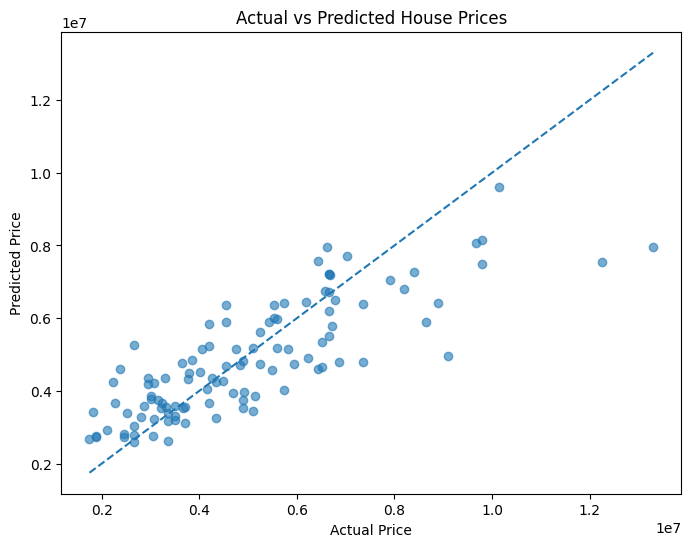

In [21]:
# Actual vs Predicted Prices

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_multiple,
    alpha=0.6
)

min_value = min(y_test.min(), y_pred_multiple.min())
max_value = max(y_test.max(), y_pred_multiple.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')

plt.show()

## Key Observations

- Simple Linear Regression used `area` as the only predictor of house price.
- Multiple Linear Regression used all available features after preprocessing.
- MAE measures the average absolute prediction error.
- MSE gives greater importance to larger prediction errors.
- R² measures how much variation in house prices is explained by the model.
- Multiple Linear Regression considers several factors simultaneously and provides a more comprehensive model.
- The regression line shows the relationship between area and price.
- The actual-versus-predicted plot helps visualize model prediction performance.
- Regression coefficients indicate the direction and estimated effect of each feature.

# Conclusion

Linear Regression was successfully implemented on the Housing Price dataset.

Simple Linear Regression was used to predict house prices using area as a single predictor. Multiple Linear Regression was then implemented using multiple numerical and encoded categorical features.

The models were evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), and R² Score. Regression visualization and coefficient analysis were also performed.

The analysis demonstrates how linear regression can be used to predict a continuous target variable such as house price and how multiple features can be used together to improve the model's predictive capability.
  